In [2]:
from ceridwen.ssps.ssp_data import collect_ssp_data_wrapper, SSPData
import numpy as np
import astropy.constants as const
import math

import jax.numpy as jnp
from jax import jit, vmap
import math
import numpy as np  # still used for file reading/parsing
from pathlib import Path
from scipy.constants import c, pi
from project_utils import open_pickled_file, setup_matplotlib_styles
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
setup_matplotlib_styles()
colors = ['dodgerblue', 'coral', 'darkviolet', 'limegreen', 'mediumvioletred', 'teal']
sns.set_palette(colors)
from astropy.constants import c, h, L_sun
path_figures = '/Users/amanda/Desktop/PhD/Tools/ceridwen/figs/neb'

In [3]:
ssp_data = SSPData.load('/Users/amanda/Desktop/PhD/Tools/ceridwen/ceridwen/data/test_data/ssp_data.h5')

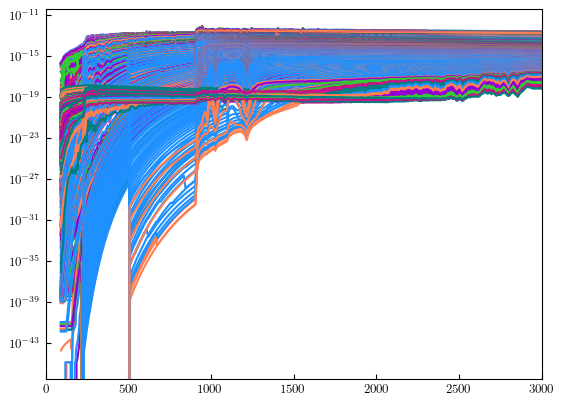

In [5]:
for a in range(len(ssp_data.ssp_lg_age_gyr)):
    for m in range(len(ssp_data.ssp_lgmet)):
        plt.plot(ssp_data.ssp_wave, ssp_data.ssp_flux[m, a, :])

plt.xlim(0, 3000)
plt.yscale('log')

In [13]:
ssp_data.log_qq.shape

(12, 108)

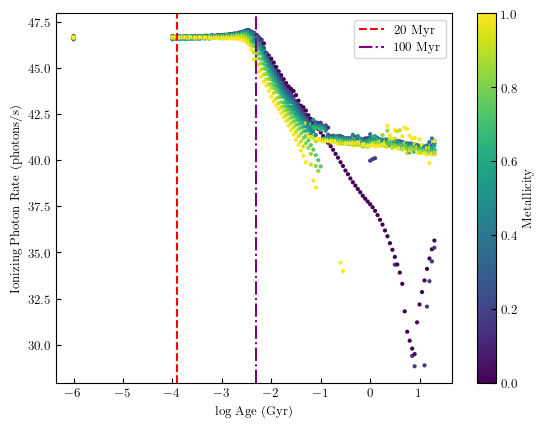

In [27]:
qq = []
age = []
met = []

for a in range(len(ssp_data.ssp_lg_age_gyr)):
    for m in range(len(ssp_data.ssp_lgmet)):
        q = ssp_data.log_qq[m, a]
        qq.append(q)
        age.append(ssp_data.ssp_lg_age_gyr[a])
        met.append(ssp_data.ssp_lgmet[m])


# Convert to arrays
age = np.array(age)
qq = np.array(qq)
met = np.array(met)

# Normalize metallicity to [0, 1] range for colormap
met_norm = (met - met.min()) / (met.max() - met.min())

# Map normalized metallicity to colors
cmap = sns.color_palette("viridis", as_cmap=True)
colors = cmap(met_norm)

# Plot
plt.figure()
plt.scatter(age, qq, c=colors, s=4)
plt.xlabel('log Age (Gyr)')
plt.ylabel('Ionizing Photon Rate (photons/s)')
#plt.axhline(y=48, color='green', linestyle='--', label='1e48 photons/s')
plt.axvline(x = np.log(20*1e6 / 1e9), color='red', linestyle='--', label='20 Myr')
plt.axvline(x = np.log(100*1e6 / 1e9), color='purple', linestyle='-.', label='100 Myr')
#plt.ylim(1e55, 1e63)
#plt.axhline(y=62, color='green', linestyle='--')
#plt.axhline(y=1e50, color='blue', linestyle='--', label='1e50 photons/s')
plt.colorbar(label='Metallicity', ax=plt.gca())
plt.legend()

(0.0, 1000.0)

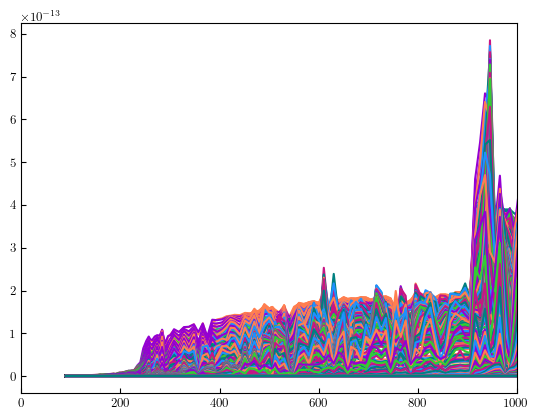

In [39]:
for i in range(ssp_data.ssp_flux_aa.shape[0]):
    for j in range(ssp_data.ssp_flux_aa.shape[1]):
        plt.plot(ssp_data.ssp_wave, ssp_data.ssp_flux[i, j, :])
plt.xlim(0, 1000)

(0.0, 1000.0)

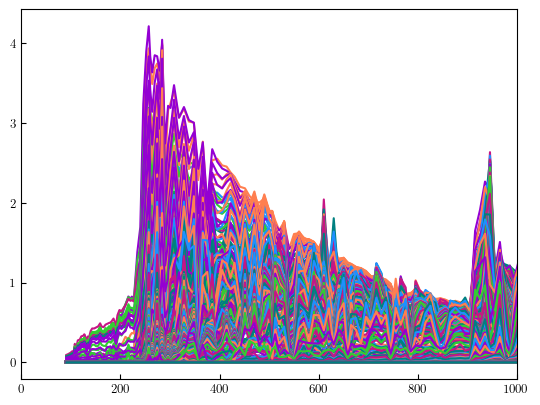

In [40]:
for i in range(ssp_data.ssp_flux_aa.shape[0]):
    for j in range(ssp_data.ssp_flux_aa.shape[1]):
        plt.plot(ssp_data.ssp_wave, ssp_data.ssp_flux_aa[i, j, :])
plt.xlim(0, 1000)